In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io
from skimage.filters import threshold_mean
import scipy.stats
import dabest
import os

import sys
sys.path.append('../')
from src.functions import get_parameters

# parameters

In [43]:
parameter_local_path = '../conf/local/parameters.yml'

parameters = get_parameters(parameter_local_path)

base_folder = parameters["data_dir"]
out_folder = parameters["out_dir"]



Parameters: 
{'key_file': 'T:/Olya/Experiments/migration_assay/in_vivo/mosaic_EC/2024-07-22_keyfile.xlsx', 'data_dir': 'T:/Olya/Experiments/migration_assay/in_vivo/mosaic_EC/new_analysis/', 'out_dir': 'T:/Olya/Experiments/migration_assay/in_vivo/mosaic_EC/new_analysis/output_notebook_2025/', 'experiment_IDs_exclude': [], 'pixel_no_per_retina': 10000, 'image_types': ['GFP'], 'load_conditions': ['CDH5CreERT2 mTmG', 'CDH5CreERT2 SMAD4 mTmG', 'CDH5CreERT2 Alk1 mTmG'], 'plot_kde': False, 'plot_individual_hist': False, 'plot_cond_kde': True, 'radial_bins': [[0, 1200]], 'time_points': ['P5_P8', 'P5_P15'], 'number_ks_test': 1}


In [44]:
px_per_cell = 300.0

# 1) Single source of truth
base_colors = {
    "ctrl":    "#000000",
    "Smad4 KO":"#0D79F2",
    "Alk1 KO": "#C333CC",
}

# 2) Build derived palettes programmatically
timepoints = ["P8", "P15"]

condition_palette = base_colors.copy()

time_condition_palette = {
    f"{cond} {tp}": base_colors[cond]
    for cond in ["ctrl", "Smad4 KO", "Alk1 KO"]
    for tp in timepoints
}

time_series_palette1 = {
    f"{cond} {tp} (P5)": base_colors[cond]
    for cond in ["ctrl", "Smad4 KO", "Alk1 KO"]
    for tp in timepoints
}

time_series_palette2 = {
    "P8 (inj. P5)":  "#ccbb44",
    "P15 (inj. P5)": "#4477aa",
}

# 3) Optional: validate that all hex strings are valid colors
import matplotlib.colors as mcolors
def _validate_palette(pal, name):
    for k, v in pal.items():
        try:
            mcolors.to_rgb(v)
        except ValueError as e:
            raise ValueError(f"Invalid color for '{k}' in {name}: {v}") from e

_validate_palette(condition_palette, "condition_palette")
_validate_palette(time_condition_palette, "time_condition_palette")
_validate_palette(time_series_palette1, "time_series_palette1")
_validate_palette(time_series_palette2, "time_series_palette2")

# Plot limits & effect size (your originals)
swarm_ylim = (0, 15)
contrast_ylim = (-4, 2)
effect_size = "mean_diff"


# load data

In [45]:
summary_data = pd.read_csv(out_folder + "summary_data.csv")
dtype_change = {'ExperimentID': int, 'collection_time': int}
summary_data = summary_data.astype(dtype_change)
summary_data

,ExperimentID,condition,collection_time,GFP_px,GFP_artery_px,GFP_vein_px,artery_px,vein_px,GFP_arterial_bed_px,GFP_venous_bed_px
0,1,ALK1-KO,8,123132.0,3236.0,4959.0,73698.0,84652.0,60885.0,54046.0
1,2,ALK1-KO,8,209482.0,3489.0,7767.0,81072.0,78389.0,112612.0,85601.0
2,3,ALK1-KO,8,77447.0,5031.0,3268.0,72773.0,69055.0,46665.0,22479.0
3,4,ALK1-KO,8,67130.0,2932.0,2256.0,58628.0,78413.0,30621.0,31317.0
4,5,ALK1-KO,15,111076.0,5475.0,6219.0,108362.0,97898.0,59073.0,40534.0
5,6,ALK1-KO,15,117460.0,6231.0,5622.0,93530.0,91598.0,72487.0,33269.0
6,7,SMAD4-KO,8,59730.0,1141.0,6172.0,66511.0,79710.0,17159.0,35258.0
7,8,SMAD4-KO,8,39907.0,1327.0,1267.0,74959.0,59340.0,19005.0,18344.0
8,9,SMAD4-KO,8,61518.0,1202.0,2331.0,89017.0,77730.0,35048.0,22925.0
9,10,SMAD4-KO,8,43387.0,1273.0,2972.0,75939.0,73877.0,24083.0,15051.0


In [46]:
# --- percentages & counts ---
summary_data = summary_data.copy()  # safe base

summary_data["percentage_artery"]       = 100.0 * summary_data["GFP_artery_px"]       / summary_data["GFP_px"]
summary_data["percentage_vein"]         = 100.0 * summary_data["GFP_vein_px"]         / summary_data["GFP_px"]
summary_data["percentage_arterial_bed"] = 100.0 * summary_data["GFP_arterial_bed_px"] / summary_data["GFP_px"]
summary_data["percentage_venous_bed"]   = 100.0 * summary_data["GFP_venous_bed_px"]   / summary_data["GFP_px"]

summary_data["labelled_ECs"]        = summary_data["GFP_px"]        / px_per_cell
summary_data["labelled_arterial_ECs"]= summary_data["GFP_artery_px"] / px_per_cell
summary_data["labelled_venous_ECs"] = summary_data["GFP_vein_px"]    / px_per_cell

# --- add inj_time from collection_time ---
inj_map = {8: "P8 (inj. P5)", 15: "P15 (inj. P5)"}
summary_data["inj_time"] = summary_data["collection_time"].map(inj_map)

# If you specifically want only those two timepoints in a separate DF:
summary_data_ts = summary_data.loc[summary_data["collection_time"].isin([8, 15])].copy()

# --- add pretty condition label without slicing ---
cond_map = {
    "control": "ctrl",
    "SMAD4-KO": "Smad4 KO",
    "ALK1-KO": "Alk1 KO",
}
summary_data["cond."] = summary_data["condition"].map(cond_map)

# If you still want separate frames (and avoid SettingWithCopyWarning):
summary_data_CTR   = summary_data.loc[summary_data["condition"] == "control"].copy()
summary_data_SMAD4 = summary_data.loc[summary_data["condition"] == "SMAD4-KO"].copy()
summary_data_Alk1  = summary_data.loc[summary_data["condition"] == "ALK1-KO"].copy()

# --- combine frames: use concat, not append ---
summary_data_combined = pd.concat(
    [summary_data_CTR, summary_data_SMAD4, summary_data_Alk1],
    ignore_index=True
)


# get mean values and SEM for reporting

In [47]:
summary_data_mean = (
    summary_data
    .groupby(["condition", "collection_time"])
    .mean(numeric_only=True)    # ignores text columns
    .reset_index()
)

# Save mean summary
out_path = os.path.join(out_folder, "summary_data_mean.csv")
summary_data_mean.to_csv(out_path, index=False)
print(f"Saved to: {out_path}")

display(summary_data_mean)

Saved to: T:/Olya/Experiments/migration_assay/in_vivo/mosaic_EC/new_analysis/output_notebook_2025/summary_data_mean.csv


,condition,collection_time,ExperimentID,GFP_px,GFP_artery_px,GFP_vein_px,artery_px,vein_px,GFP_arterial_bed_px,GFP_venous_bed_px,percentage_artery,percentage_vein,percentage_arterial_bed,percentage_venous_bed,labelled_ECs,labelled_arterial_ECs,labelled_venous_ECs
0,ALK1-KO,8,28.900000,84271.000000,2061.800000,3884.800000,72180.200000,80306.900000,41726.100000,36597.000000,2.368756,4.710740,49.022329,43.892441,280.903333,6.872667,12.949333
1,ALK1-KO,15,36.166667,62785.666667,4464.166667,2694.833333,97328.666667,78947.000000,36536.666667,19163.500000,8.601813,3.302749,59.520886,28.640765,209.285556,14.880556,8.982778
2,SMAD4-KO,8,15.500000,59414.875000,1388.250000,3196.250000,75346.625000,83648.375000,25018.750000,29834.625000,2.418912,5.431116,43.026934,49.162847,198.049583,4.627500,10.654167
3,SMAD4-KO,15,20.500000,62686.785714,6433.000000,3036.214286,118547.500000,82940.785714,39268.857143,14101.428571,9.673445,4.663767,63.003093,22.805351,208.955952,21.443333,10.120714
4,control,8,31.500000,52738.375000,2569.250000,3030.875000,55738.625000,56271.125000,24226.250000,23122.250000,6.144931,5.204760,51.200266,37.866617,175.794583,8.564167,10.102917
5,control,15,39.500000,66286.000000,5621.750000,3136.375000,98862.625000,76209.125000,36796.000000,20816.375000,8.853383,4.363039,57.280049,29.637097,220.953333,18.739167,10.454583


In [48]:
summary_data_sem = (
    summary_data
    .groupby(["condition", "collection_time"])
    .sem(numeric_only=True)       # <- key fix
    .reset_index()
)

# Save to CSV
out_path = os.path.join(out_folder, "summary_data_sem.csv")
summary_data_sem.to_csv(out_path, index=False)
print(f"Saved to: {out_path}")

# Show in notebook
display(summary_data_sem)

#summary_data.groupby(by=["time_interval"]).sem()

Saved to: T:/Olya/Experiments/migration_assay/in_vivo/mosaic_EC/new_analysis/output_notebook_2025/summary_data_sem.csv


,condition,collection_time,ExperimentID,GFP_px,GFP_artery_px,GFP_vein_px,artery_px,vein_px,GFP_arterial_bed_px,GFP_venous_bed_px,percentage_artery,percentage_vein,percentage_arterial_bed,percentage_venous_bed,labelled_ECs,labelled_arterial_ECs,labelled_venous_ECs
0,ALK1-KO,8,7.202546,18974.317074,529.955717,851.025588,3039.757314,5363.184950,9891.208267,8277.283559,0.568298,0.352867,2.099411,2.250215,63.247724,1.766519,2.836752
1,ALK1-KO,15,9.707099,18605.150000,986.161597,1116.071904,2476.108636,7468.893332,10605.532040,6341.947738,1.292299,0.858539,1.697464,1.784304,62.017167,3.287205,3.720240
2,SMAD4-KO,8,5.545268,4536.069635,258.183749,506.902137,2889.635203,5951.790550,2157.867273,3848.252493,0.432370,0.842696,3.634216,3.602973,15.120232,0.860612,1.689674
3,SMAD4-KO,15,1.118034,8638.528947,1212.818808,537.017324,4183.505520,3247.101221,5238.779890,2171.446436,0.698049,0.448579,1.948788,2.060246,28.795096,4.042729,1.790058
4,control,8,0.866025,18756.880350,638.054654,1185.624661,6452.375089,10166.009644,8357.650272,9663.032602,1.002331,0.891203,3.573639,3.468236,62.522934,2.126849,3.952082
5,control,15,0.866025,9781.375389,642.514056,740.240886,6187.529483,3079.927379,4137.703530,5293.842808,0.771560,0.401851,3.144482,3.680831,32.604585,2.141714,2.467470


Conditions present in plot_df: ['Alk1 KO P8', 'Alk1 KO P15', 'Smad4 KO P8', 'Smad4 KO P15', 'ctrl P8', 'ctrl P15']
Categories (6, object): ['ctrl P8' < 'ctrl P15' < 'Smad4 KO P8' < 'Smad4 KO P15' < 'Alk1 KO P8' < 'Alk1 KO P15']
DABEST v2025.03.27
                  
Good evening!
The current time is Tue Sep 30 12:59:44 2025.

The unpaired mean difference between ctrl P8 and ctrl P15 is 2.71 [95%CI 0.165, 4.88].
The p-value of the two-sided permutation t-test is 0.0538, calculated for legacy purposes only. 

The unpaired mean difference between Smad4 KO P8 and Smad4 KO P15 is 7.25 [95%CI 5.59, 8.7].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

The unpaired mean difference between Alk1 KO P8 and Alk1 KO P15 is 6.23 [95%CI 3.6, 8.69].
The p-value of the two-sided permutation t-test is 0.0006, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value repor

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,...,pvalue_mann_whitney,statistic_mann_whitney,bec_difference,bec_bootstraps,bec_bca_interval_idx,bec_bca_low,bec_bca_high,bec_pct_interval_idx,bec_pct_low,bec_pct_high
0,ctrl P8,ctrl P15,8,8,mean difference,None,2.708452,95,0.165346,4.879230,...,0.064957,14.0,0.0,"[0.5801146465742972, 0.10708041793846323, -0.2...","(127, 4877)",-2.648125,2.597713,"(125, 4875)",-2.655446,2.593122
1,Smad4 KO P8,Smad4 KO P15,8,14,mean difference,None,7.254533,95,5.594607,8.695849,...,0.000006,0.0,0.0,"[0.04618064139525391, -0.08317072528427527, -0...","(129, 4879)",-1.132285,1.121375,"(125, 4875)",-1.140837,1.118127
2,Alk1 KO P8,Alk1 KO P15,10,6,mean difference,None,6.233057,95,3.597515,8.687106,...,0.000999,2.0,0.0,"[0.5102470704286883, 0.9373956155226941, 1.264...","(126, 4876)",-1.519782,1.507997,"(125, 4875)",-1.520824,1.503990


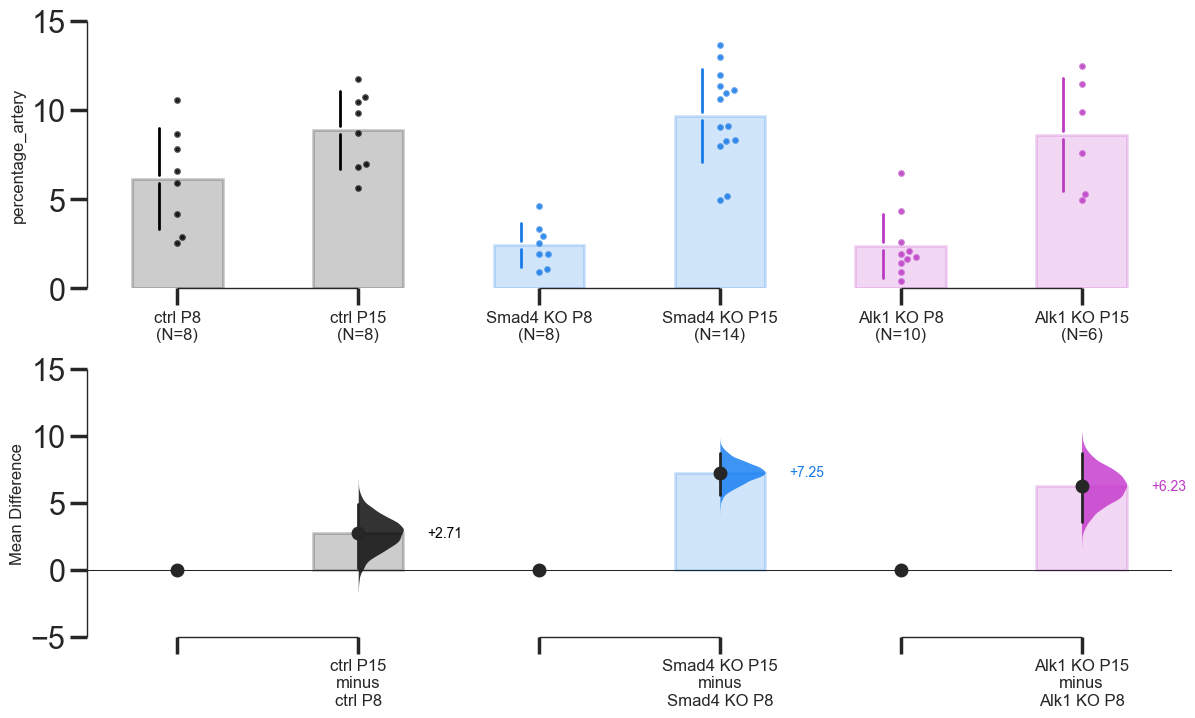

In [50]:
#new code without .append
# -----------------------------
# Build plot_df directly
# -----------------------------
cond_map = {"control": "ctrl", "SMAD4-KO": "Smad4 KO", "ALK1-KO": "Alk1 KO"}
time_map = {8: "P8", 15: "P15"}

plot_df = (
    summary_data
    .query("collection_time in [8, 15]")
    .assign(
        cond_simple=lambda d: d["condition"].map(cond_map),
        time_simple=lambda d: d["collection_time"].map(time_map),
        condition=lambda d: d["cond_simple"] + " " + d["time_simple"]
    )[["percentage_artery", "condition"]]
)

# enforce plotting order to match idx below
order = [
    "ctrl P8","ctrl P15",
    "Smad4 KO P8","Smad4 KO P15",
    "Alk1 KO P8","Alk1 KO P15"
]
plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=order, ordered=True)

print("Conditions present in plot_df:", plot_df["condition"].unique())

# -----------------------------
# Palette (fix missing #)
# -----------------------------
time_condition_palette = {
    "ctrl P8": "#000000",  "ctrl P15": "#000000",
    "Smad4 KO P8": "#0D79F2", "Smad4 KO P15": "#0D79F2",
    "Alk1 KO P8": "#C333CC",  "Alk1 KO P15": "#C333CC"
}

# -----------------------------
# DABEST
# -----------------------------
properties_dabest = dabest.load(
    data=plot_df, x="condition", y="percentage_artery",
    idx=(
        ("ctrl P8","ctrl P15"),
        ("Smad4 KO P8","Smad4 KO P15"),
        ("Alk1 KO P8","Alk1 KO P15"),
    )
)

print(properties_dabest.mean_diff)
display(properties_dabest.mean_diff.results)

# -----------------------------
# Plot
# -----------------------------
fig = properties_dabest.mean_diff.plot(
    raw_ylim=(0, 15),             # tighten as needed
    contrast_ylim=(-5, 15),
    custom_palette=time_condition_palette,
    raw_marker_size=2,          # smaller points
    raw_alpha=0.7,
    raw_desat=0.9
)
fig.set_size_inches(14, 8)

# Save
fig.savefig(os.path.join(out_folder, "percentage_mean_artery_P8_P15_300925.pdf"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_folder, "percentage_mean_artery_P8_P15_300925.png"), dpi=300, bbox_inches="tight")



Conditions present in plot_df: ['Alk1 KO P8', 'Alk1 KO P15', 'Smad4 KO P8', 'Smad4 KO P15', 'ctrl P8', 'ctrl P15']
Categories (6, object): ['ctrl P8' < 'ctrl P15' < 'Smad4 KO P8' < 'Smad4 KO P15' < 'Alk1 KO P8' < 'Alk1 KO P15']
DABEST v2025.03.27
                  
Good afternoon!
The current time is Tue Sep 30 13:34:42 2025.

The unpaired mean difference between ctrl P8 and ctrl P15 is -0.842 [95%CI -2.79, 0.781].
The p-value of the two-sided permutation t-test is 0.4, calculated for legacy purposes only. 

The unpaired mean difference between Smad4 KO P8 and Smad4 KO P15 is -0.767 [95%CI -3.0, 0.637].
The p-value of the two-sided permutation t-test is 0.393, calculated for legacy purposes only. 

The unpaired mean difference between Alk1 KO P8 and Alk1 KO P15 is -1.41 [95%CI -3.21, 0.0942].
The p-value of the two-sided permutation t-test is 0.107, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,...,pvalue_mann_whitney,statistic_mann_whitney,bec_difference,bec_bootstraps,bec_bca_interval_idx,bec_bca_low,bec_bca_high,bec_pct_interval_idx,bec_pct_low,bec_pct_high
0,ctrl P8,ctrl P15,8,8,mean difference,None,-0.841721,95,-2.789664,0.781269,...,0.959130,33.0,0.0,"[0.2776278181492655, -1.4667359471499548, 1.20...","(122, 4872)",-2.356437,2.277740,"(125, 4875)",-2.346380,2.278452
1,Smad4 KO P8,Smad4 KO P15,8,14,mean difference,None,-0.767349,95,-3.002206,0.637137,...,0.569891,65.0,0.0,"[0.4123855414975903, -0.6099705053365563, -0.5...","(115, 4865)",-2.242338,2.118537,"(125, 4875)",-2.212133,2.168901
2,Alk1 KO P8,Alk1 KO P15,10,6,mean difference,None,-1.407991,95,-3.214148,0.094176,...,0.313187,40.0,0.0,"[0.25232792931391135, -0.7570065328455033, -0....","(120, 4870)",-0.924688,0.898120,"(125, 4875)",-0.915878,0.905837


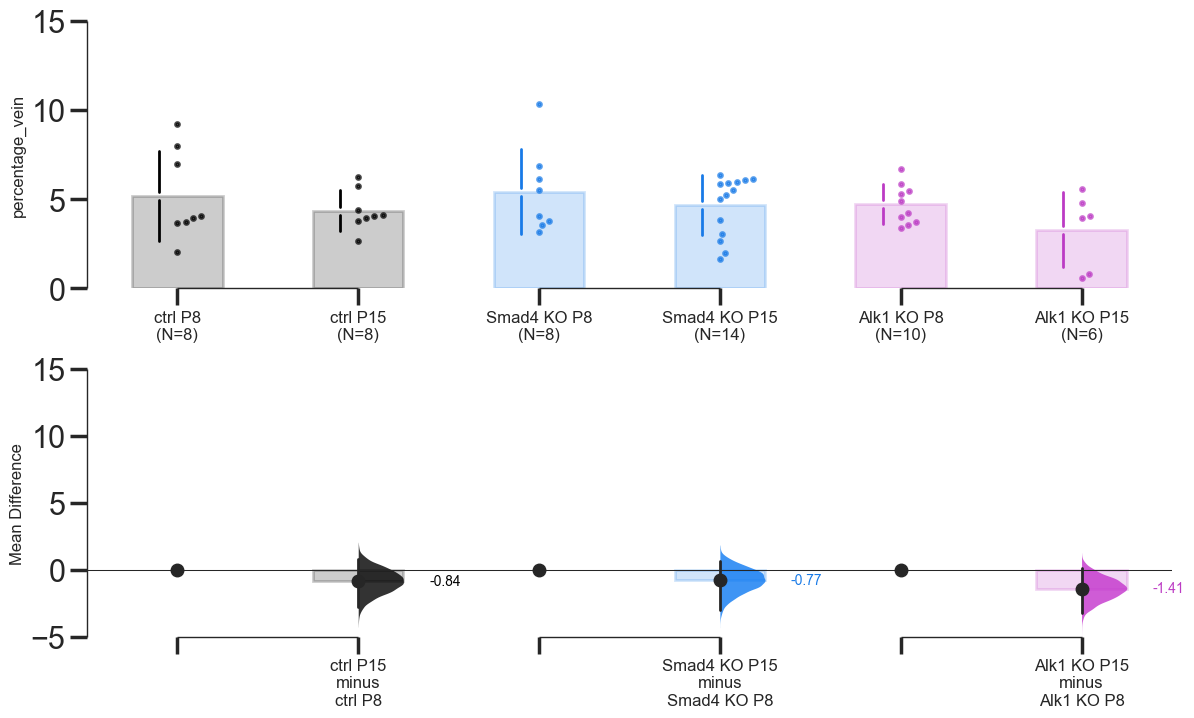

In [62]:
#new code without .append
# -----------------------------
# Build plot_df directly
# -----------------------------
cond_map = {"control": "ctrl", "SMAD4-KO": "Smad4 KO", "ALK1-KO": "Alk1 KO"}
time_map = {8: "P8", 15: "P15"}

plot_df = (
    summary_data
    .query("collection_time in [8, 15]")
    .assign(
        cond_simple=lambda d: d["condition"].map(cond_map),
        time_simple=lambda d: d["collection_time"].map(time_map),
        condition=lambda d: d["cond_simple"] + " " + d["time_simple"]
    )[["percentage_vein", "condition"]]
)

# enforce plotting order to match idx below
order = [
    "ctrl P8","ctrl P15",
    "Smad4 KO P8","Smad4 KO P15",
    "Alk1 KO P8","Alk1 KO P15"
]
plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=order, ordered=True)

print("Conditions present in plot_df:", plot_df["condition"].unique())

# -----------------------------
# Palette (fix missing #)
# -----------------------------
time_condition_palette = {
    "ctrl P8": "#000000",  "ctrl P15": "#000000",
    "Smad4 KO P8": "#0D79F2", "Smad4 KO P15": "#0D79F2",
    "Alk1 KO P8": "#C333CC",  "Alk1 KO P15": "#C333CC"
}

# -----------------------------
# DABEST
# -----------------------------
properties_dabest = dabest.load(
    data=plot_df, x="condition", y="percentage_vein",
    idx=(
        ("ctrl P8","ctrl P15"),
        ("Smad4 KO P8","Smad4 KO P15"),
        ("Alk1 KO P8","Alk1 KO P15"),
    )
)

print(properties_dabest.mean_diff)
display(properties_dabest.mean_diff.results)

# -----------------------------
# Plot
# -----------------------------
fig = properties_dabest.mean_diff.plot(
    raw_ylim=(0, 15),             # tighten as needed
    contrast_ylim=(-5, 15),
    custom_palette=time_condition_palette,
    raw_marker_size=2,          # smaller points
    raw_alpha=0.7,
    raw_desat=0.9
)
fig.set_size_inches(14, 8)

# Save
fig.savefig(os.path.join(out_folder, "percentage_mean_vein_P8_P15_300925.pdf"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_folder, "percentage_mean_vein_P8_P15_300925.png"), dpi=300, bbox_inches="tight")



In [53]:
print(results_df.columns)


Index(['control', 'test', 'control_N', 'test_N', 'effect_size', 'is_paired',
       'difference', 'ci', 'bca_low', 'bca_high', 'bca_interval_idx',
       'pct_low', 'pct_high', 'pct_interval_idx', 'bootstraps', 'resamples',
       'random_seed', 'permutations', 'pvalue_permutation',
       'permutation_count', 'permutations_var', 'pvalue_welch',
       'statistic_welch', 'pvalue_students_t', 'statistic_students_t',
       'pvalue_mann_whitney', 'statistic_mann_whitney', 'bec_difference',
       'bec_bootstraps', 'bec_bca_interval_idx', 'bec_bca_low', 'bec_bca_high',
       'bec_pct_interval_idx', 'bec_pct_low', 'bec_pct_high'],
      dtype='object')


In [54]:
display(results_df)

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,...,pvalue_mann_whitney,statistic_mann_whitney,bec_difference,bec_bootstraps,bec_bca_interval_idx,bec_bca_low,bec_bca_high,bec_pct_interval_idx,bec_pct_low,bec_pct_high
0,ctrl P8,ctrl P15,8,8,mean difference,None,2.708452,95,0.165346,4.879230,...,0.064957,14.0,0.0,"[0.5801146465742972, 0.10708041793846323, -0.2...","(127, 4877)",-2.648125,2.597713,"(125, 4875)",-2.655446,2.593122
1,Smad4 KO P8,Smad4 KO P15,8,14,mean difference,None,7.254533,95,5.594607,8.695849,...,0.000006,0.0,0.0,"[0.04618064139525391, -0.08317072528427527, -0...","(129, 4879)",-1.132285,1.121375,"(125, 4875)",-1.140837,1.118127
2,Alk1 KO P8,Alk1 KO P15,10,6,mean difference,None,6.233057,95,3.597515,8.687106,...,0.000999,2.0,0.0,"[0.5102470704286883, 0.9373956155226941, 1.264...","(126, 4876)",-1.519782,1.507997,"(125, 4875)",-1.520824,1.503990


DABEST v2025.03.27
                  
Good evening!
The current time is Thu Sep 25 12:09:15 2025.

The unpaired mean difference between ctrl P8 and Smad4 KO P8 is -3.73 [95%CI -5.78, -1.71].
The p-value of the two-sided permutation t-test is 0.0042, calculated for legacy purposes only. 

The unpaired mean difference between ctrl P8 and Alk1 KO P8 is -3.78 [95%CI -5.81, -1.64].
The p-value of the two-sided permutation t-test is 0.005, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To get the results of all valid statistical tests, use `.mean_diff.statistical_tests`


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,...,pvalue_mann_whitney,statistic_mann_whitney,bec_difference,bec_bootstraps,bec_bca_interval_idx,bec_bca_low,bec_bca_high,bec_pct_interval_idx,bec_pct_low,bec_pct_high
0,ctrl P8,Smad4 KO P8,8,8,mean difference,None,-3.726018,95,-5.781853,-1.706056,...,0.010412,56.0,0.0,"[0.5801146465742972, 0.10708041793846323, -0.2...","(127, 4877)",-2.648125,2.597713,"(125, 4875)",-2.655446,2.593122
1,ctrl P8,Alk1 KO P8,8,10,mean difference,None,-3.776174,95,-5.811773,-1.641577,...,0.003062,72.0,0.0,"[0.5801146465742972, 0.10708041793846323, -0.2...","(127, 4877)",-2.648125,2.597713,"(125, 4875)",-2.655446,2.593122


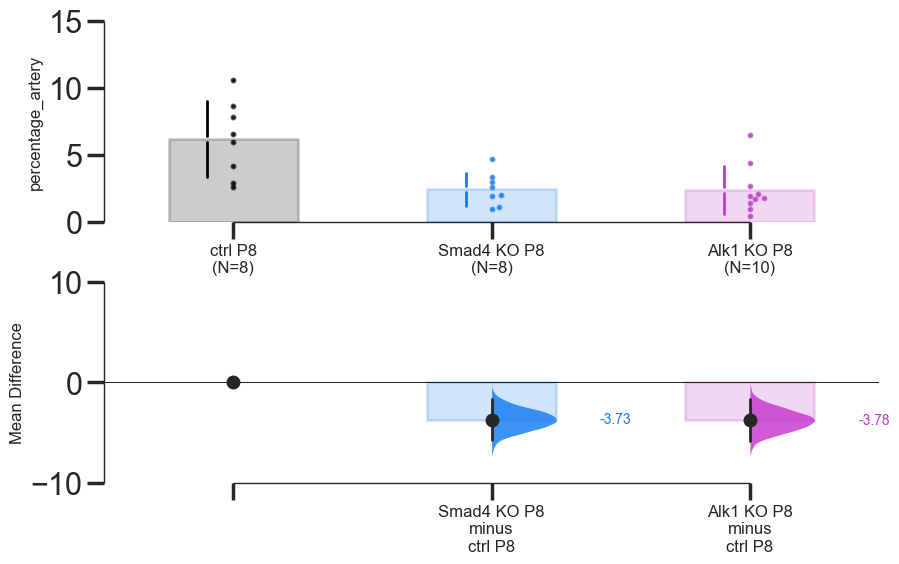

In [30]:
plot_df_p8 = plot_df[plot_df["condition"].isin(
    ["ctrl P8","Smad4 KO P8","Alk1 KO P8"]
)].copy()

# Drop unused categories so only the 3 P8 levels remain
plot_df_p8["condition"] = plot_df_p8["condition"].cat.remove_unused_categories()

properties_p8 = dabest.load(
    data=plot_df_p8, x="condition", y="percentage_artery",
    idx=('ctrl P8','Smad4 KO P8','Alk1 KO P8')  # shared-control
)


print(properties_p8.mean_diff)
display(properties_p8.mean_diff.results)

fig = properties_p8.mean_diff.plot(
    custom_palette=time_condition_palette,
    raw_ylim=(0, 15),
    contrast_ylim=(-10, 10),
    raw_marker_size=1.2,
    raw_alpha=0.7,
    raw_desat=0.9
)
fig.set_size_inches(10, 6)
fig.savefig(os.path.join(out_folder, "percentage_artery_P8.pdf"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_folder, "percentage_artery_P8.png"), dpi=300, bbox_inches="tight")



['ctrl P8', 'ctrl P15', 'Smad4 KO P8', 'Smad4 KO P15', 'Alk1 KO P8', 'Alk1 KO P15']
Categories (6, object): ['ctrl P8' < 'ctrl P15' < 'Smad4 KO P8' < 'Smad4 KO P15' < 'Alk1 KO P8' < 'Alk1 KO P15']
DABEST v2025.03.27
                  
Good afternoon!
The current time is Tue Sep 30 13:06:32 2025.

The unpaired mean difference between ctrl P8 and ctrl P15 is 6.08 [95%CI -2.14, 15.3].
The p-value of the two-sided permutation t-test is 0.237, calculated for legacy purposes only. 

The unpaired mean difference between Smad4 KO P8 and Smad4 KO P15 is 20.0 [95%CI 12.2, 27.5].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

The unpaired mean difference between Alk1 KO P8 and Alk1 KO P15 is 10.5 [95%CI 5.35, 15.1].
The p-value of the two-sided permutation t-test is 0.0064, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of ob

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,...,pvalue_mann_whitney,statistic_mann_whitney,bec_difference,bec_bootstraps,bec_bca_interval_idx,bec_bca_low,bec_bca_high,bec_pct_interval_idx,bec_pct_low,bec_pct_high
0,ctrl P8,ctrl P15,8,8,mean difference,None,6.079782,95,-2.143573,15.345660,...,0.382284,23.0,0.0,"[-0.8614383359460476, 5.752558430780439, -1.29...","(124, 4874)",-9.255833,9.572484,"(125, 4875)",-9.235853,9.610028
1,Smad4 KO P8,Smad4 KO P15,8,14,mean difference,None,19.976158,95,12.235428,27.484206,...,0.000075,4.0,0.0,"[1.5919828433005634, 0.5434938723622196, 0.182...","(117, 4866)",-9.679561,9.312341,"(125, 4875)",-9.575015,9.490245
2,Alk1 KO P8,Alk1 KO P15,10,6,mean difference,None,10.498557,95,5.348605,15.113289,...,0.004745,5.0,0.0,"[-2.280357529737408, 4.0591985208646335, 6.930...","(129, 4879)",-5.505537,5.699195,"(125, 4875)",-5.550172,5.642225


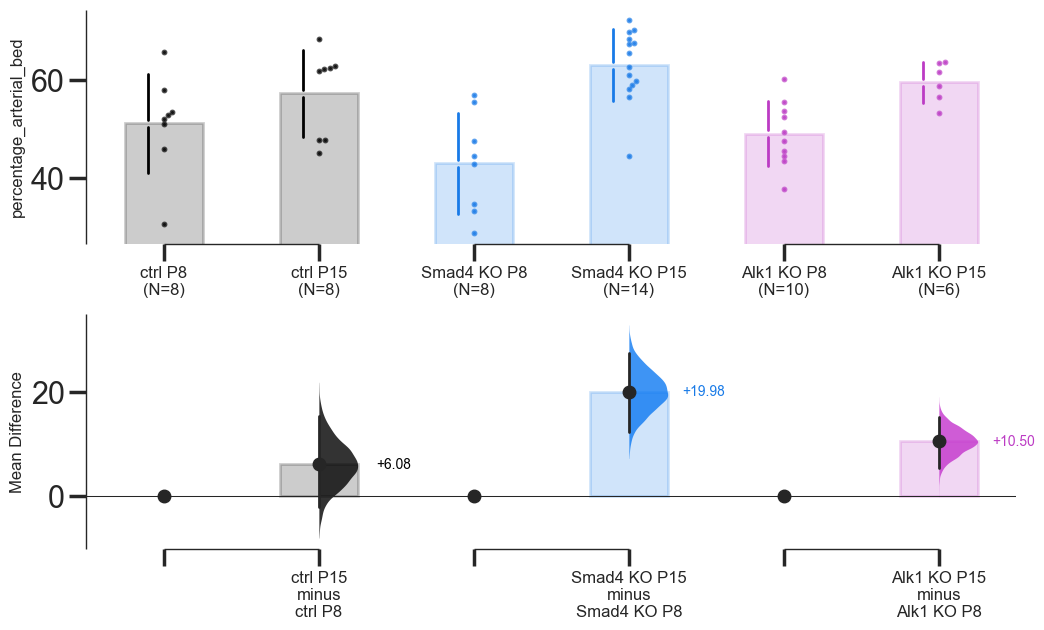

In [56]:
# --- 1) Make the P8 / P15 subsets (safe .copy()) ---
summary_data_P5_P8  = summary_data.loc[summary_data["collection_time"] == 8].copy()
summary_data_P5_P15 = summary_data.loc[summary_data["collection_time"] == 15].copy()

# --- 2) Pull numpy arrays for percentage_arterial_bed per condition ---
def vals(df, cond):
    return df.loc[df["condition"] == cond, "percentage_arterial_bed"].to_numpy()

ctrl_p8   = vals(summary_data_P5_P8,  "control")
ctrl_p15  = vals(summary_data_P5_P15, "control")
SMAD4_p8  = vals(summary_data_P5_P8,  "SMAD4-KO")
SMAD4_p15 = vals(summary_data_P5_P15, "SMAD4-KO")
Alk1_p8   = vals(summary_data_P5_P8,  "ALK1-KO")
Alk1_p15  = vals(summary_data_P5_P15, "ALK1-KO")

# --- 3) Build plot_df (no .append), set order/categorical ---
frames = [
    pd.DataFrame({"percentage_arterial_bed": ctrl_p8,   "condition": "ctrl P8"}),
    pd.DataFrame({"percentage_arterial_bed": ctrl_p15,  "condition": "ctrl P15"}),
    pd.DataFrame({"percentage_arterial_bed": SMAD4_p8,  "condition": "Smad4 KO P8"}),
    pd.DataFrame({"percentage_arterial_bed": SMAD4_p15, "condition": "Smad4 KO P15"}),
    pd.DataFrame({"percentage_arterial_bed": Alk1_p8,   "condition": "Alk1 KO P8"}),
    pd.DataFrame({"percentage_arterial_bed": Alk1_p15,  "condition": "Alk1 KO P15"}),
]
plot_df = pd.concat(frames, ignore_index=True)

order = [
    "ctrl P8","ctrl P15",
    "Smad4 KO P8","Smad4 KO P15",
    "Alk1 KO P8","Alk1 KO P15",
]
plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=order, ordered=True)

print(plot_df["condition"].unique())

# --- 4) DABEST: compare P15 vs P8 within each condition ---
properties_dabest = dabest.load(
    data=plot_df, x="condition", y="percentage_arterial_bed",
    idx=(("ctrl P8","ctrl P15"),
         ("Smad4 KO P8","Smad4 KO P15"),
         ("Alk1 KO P8","Alk1 KO P15"))
)

print(properties_dabest.mean_diff)
display(properties_dabest.mean_diff.results)

# --- 5) Plot & save ---
# make sure your palette has leading '#' for Alk1 entries
time_condition_palette = {
    "ctrl P8": "#000000",  "ctrl P15": "#000000",
    "Smad4 KO P8": "#0D79F2", "Smad4 KO P15": "#0D79F2",
    "Alk1 KO P8": "#C333CC",  "Alk1 KO P15": "#C333CC",
}

fig = properties_dabest.mean_diff.plot(
    custom_palette=time_condition_palette,
    raw_marker_size=1.2, raw_alpha=0.7, raw_desat=0.9,
    # adjust y-lims to your data range if needed:
    # raw_ylim=(0, 60), contrast_ylim=(-30, 30),
)
fig.set_size_inches(12, 7)

fig.savefig(os.path.join(out_folder, "percentage_arterial_bed_P8_P15_300925.pdf"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_folder, "percentage_arterial_bed_P8_P15_300925.png"), dpi=300, bbox_inches="tight")


DABEST v2024.03.29
                  
Good afternoon!
The current time is Thu Jul 25 17:15:49 2024.

The unpaired mean difference between ctrl P15 and Smad4 KO P15 is 5.92 [95%CI -0.405, 13.2].
The p-value of the two-sided permutation t-test is 0.095, calculated for legacy purposes only. 

The unpaired mean difference between ctrl P15 and Alk1 KO P15 is 2.24 [95%CI -3.95, 9.1].
The p-value of the two-sided permutation t-test is 0.57, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To get the results of all valid statistical tests, use `.mean_diff.statistical_tests`


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,...,permutations,pvalue_permutation,permutation_count,permutations_var,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,ctrl P15,Smad4 KO P15,8,14,mean difference,None,5.916773,95,-0.404967,13.174142,...,"[2.511428520980701, -3.119353543882191, 6.8214...",0.0950,5000,"[13.54833874032741, 13.909897206997963, 11.181...",0.129597,-1.630245,0.093800,-1.759393,0.211852,37.0
1,ctrl P15,Alk1 KO P15,8,6,mean difference,None,2.240837,95,-3.949583,9.098493,...,"[0.8976352113256922, 2.3894398962893604, -3.11...",0.5702,5000,"[15.817540608427823, 16.40293855693436, 15.054...",0.544078,-0.627089,0.580451,-0.568087,0.851815,22.0


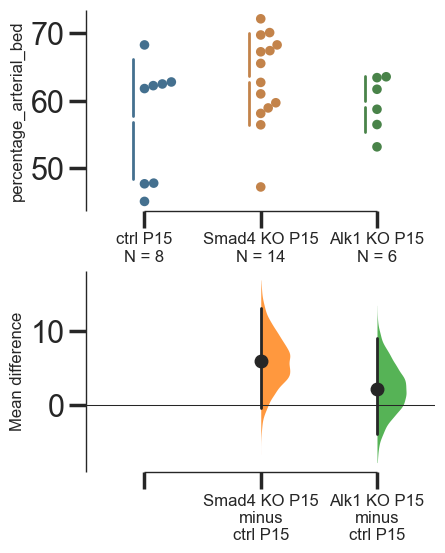

In [12]:

properties_dabest = dabest.load(data = plot_df, x="condition", y="percentage_arterial_bed",
                          idx=(( 'ctrl P15',  'Smad4 KO P15',  'Alk1 KO P15')))

print(properties_dabest.mean_diff)
display(properties_dabest.mean_diff.results)

#properties_dabest = dabest.load(data = summary_data_CTR, x="time_interval", y="labelled_arterial_ECs",
#                          idx=('P8_P9', 'P5_P6', 'P5_P7', 'P5_P8', 'P5_P9'))

# Produce a Cumming estimation plot.
#test = properties_dabest.mean_diff.plot(swarm_ylim=(0, 10), contrast_ylim=(-3, 2));
#test = properties_dabest.mean_diff.plot(swarm_ylim=swarm_ylim, custom_palette = time_condition_palette) #, contrast_ylim=(-4, 2));
test = properties_dabest.mean_diff.plot(custom_palette = time_condition_palette) #, contrast_ylim=(-4, 2));

test.savefig(out_folder + "percentage_arterial_bed_P15.pdf")
test.savefig(out_folder + "percentage_arterial_bed_P15.png")

C:\Users\ooppenh\AppData\Local\Temp\ipykernel_1664\92723391.py:7: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(plot_df_p8["condition"]):


DABEST v2025.03.27
                  
Good evening!
The current time is Thu Sep 25 12:53:50 2025.

The unpaired mean difference between ctrl P8 and Smad4 KO P8 is -8.17 [95%CI -16.8, 1.73].
The p-value of the two-sided permutation t-test is 0.131, calculated for legacy purposes only. 

The unpaired mean difference between ctrl P8 and Alk1 KO P8 is -2.18 [95%CI -8.78, 6.73].
The p-value of the two-sided permutation t-test is 0.599, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To get the results of all valid statistical tests, use `.mean_diff.statistical_tests`


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,...,pvalue_mann_whitney,statistic_mann_whitney,bec_difference,bec_bootstraps,bec_bca_interval_idx,bec_bca_low,bec_bca_high,bec_pct_interval_idx,bec_pct_low,bec_pct_high
0,ctrl P8,Smad4 KO P8,8,8,mean difference,None,-8.173332,95,-16.789505,1.732029,...,0.160528,46.0,0.0,"[-0.8614383359460476, 5.752558430780439, -1.29...","(124, 4874)",-9.255833,9.572484,"(125, 4875)",-9.235853,9.610028
1,ctrl P8,Alk1 KO P8,8,10,mean difference,None,-2.177938,95,-8.784910,6.733123,...,0.459756,49.0,0.0,"[-0.8614383359460476, 5.752558430780439, -1.29...","(124, 4874)",-9.255833,9.572484,"(125, 4875)",-9.235853,9.610028


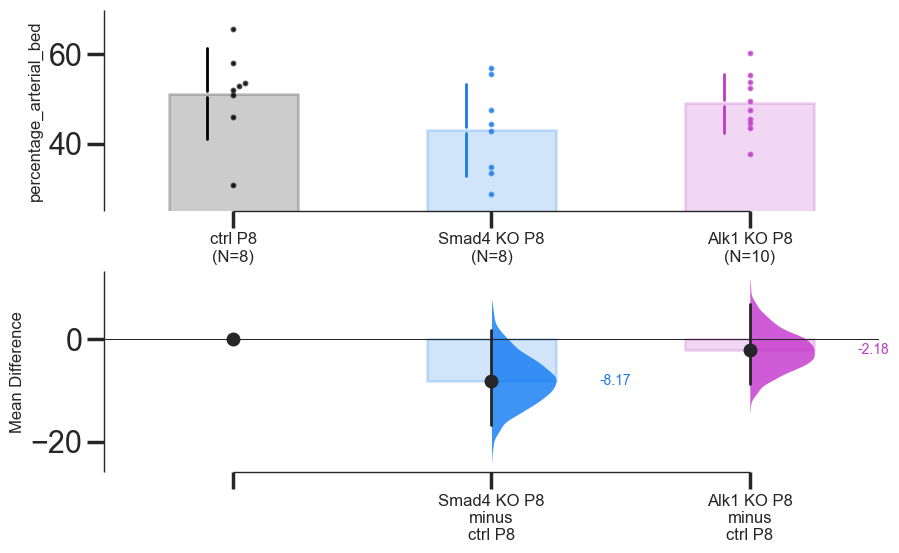

In [34]:
# --- subset to P8 only ---
plot_df_p8 = plot_df.loc[
    plot_df["condition"].isin(["ctrl P8", "Smad4 KO P8", "Alk1 KO P8"])
].copy()

# If 'condition' is categorical, drop unused categories to avoid reorder errors.
if pd.api.types.is_categorical_dtype(plot_df_p8["condition"]):
    plot_df_p8["condition"] = plot_df_p8["condition"].cat.remove_unused_categories()

# --- DABEST: shared-control at P8 (first item is the control) ---
properties_p8 = dabest.load(
    data=plot_df_p8,
    x="condition",
    y="percentage_arterial_bed",
    idx=("ctrl P8", "Smad4 KO P8", "Alk1 KO P8"),
)

print(properties_p8.mean_diff)
display(properties_p8.mean_diff.results)

# palette restricted to the three P8 keys
p8_palette = {
    "ctrl P8":    "#000000",
    "Smad4 KO P8":"#0D79F2",
    "Alk1 KO P8": "#C333CC",
}

# Optional: tidy y-limits based on data
y_lo = max(0, np.floor(plot_df_p8["percentage_arterial_bed"].min() / 5) * 5)
y_hi = np.ceil(plot_df_p8["percentage_arterial_bed"].max() / 5) * 5

fig = properties_p8.mean_diff.plot(
    custom_palette=p8_palette,
    raw_marker_size=1.2,
    raw_alpha=0.7,
    raw_desat=0.9,
    raw_ylim=(y_lo, y_hi),        # or set to a fixed range if you prefer
)
fig.set_size_inches(10, 6)

fig.savefig(os.path.join(out_folder, "percentage_arterial_bed_P8.pdf"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_folder, "percentage_arterial_bed_P8.png"), dpi=300, bbox_inches="tight")


DABEST v2024.03.29
                  
Good afternoon!
The current time is Thu Jul 25 17:17:09 2024.

The unpaired mean difference between ctrl P15 and Smad4 KO P15 is 0.301 [95%CI -0.957, 1.3].
The p-value of the two-sided permutation t-test is 0.662, calculated for legacy purposes only. 

The unpaired mean difference between ctrl P15 and Alk1 KO P15 is -1.06 [95%CI -2.88, 0.478].
The p-value of the two-sided permutation t-test is 0.255, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To get the results of all valid statistical tests, use `.mean_diff.statistical_tests`


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,...,permutations,pvalue_permutation,permutation_count,permutations_var,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,ctrl P15,Smad4 KO P15,8,14,mean difference,None,0.300728,95,-0.956602,1.301105,...,"[-1.0321284960149413, 0.5103716544124897, -0.1...",0.6618,5000,"[0.45147547836332763, 0.4847261926192518, 0.45...",0.623205,-0.499338,0.658227,-0.449046,0.616343,48.0
1,ctrl P15,Alk1 KO P15,8,6,mean difference,None,-1.060290,95,-2.877818,0.478346,...,"[0.49699847358891835, -0.09697003156468398, 0....",0.2552,5000,"[0.8924609773169336, 0.8588130798132406, 0.716...",0.299340,1.118531,0.246472,1.218436,0.572761,29.0


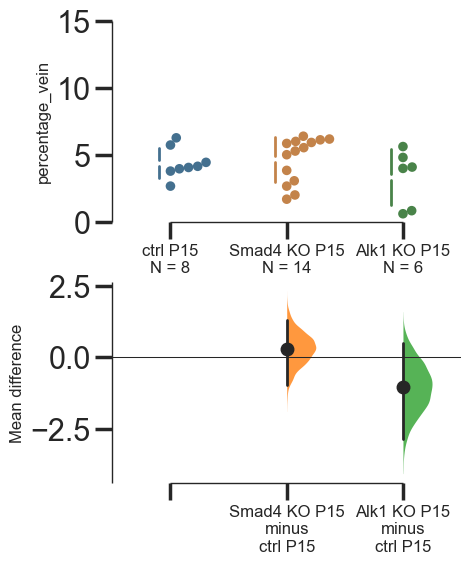

In [15]:
properties_dabest = dabest.load(data = plot_df, x="condition", y="percentage_vein",
                          idx=(( 'ctrl P15',  'Smad4 KO P15',  'Alk1 KO P15')))

print(properties_dabest.mean_diff)
display(properties_dabest.mean_diff.results)

#properties_dabest = dabest.load(data = summary_data_CTR, x="time_interval", y="labelled_arterial_ECs",
#                          idx=('P8_P9', 'P5_P6', 'P5_P7', 'P5_P8', 'P5_P9'))

# Produce a Cumming estimation plot.
#test = properties_dabest.mean_diff.plot(swarm_ylim=(0, 10), contrast_ylim=(-3, 2));
test = properties_dabest.mean_diff.plot(swarm_ylim=swarm_ylim, custom_palette = time_condition_palette) #, contrast_ylim=(-4, 2));
test.savefig(out_folder + "percentage_vein_P15.pdf")
test.savefig(out_folder + "percentage_vein_P15.png")

DABEST v2025.03.27
                  
Good afternoon!
The current time is Thu Sep 25 13:43:16 2025.

The unpaired mean difference between ctrl P8 and ctrl P15 is -8.23 [95%CI -18.0, 0.611].
The p-value of the two-sided permutation t-test is 0.127, calculated for legacy purposes only. 

The unpaired mean difference between Smad4 KO P8 and Smad4 KO P15 is -26.4 [95%CI -33.7, -18.2].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

The unpaired mean difference between Alk1 KO P8 and Alk1 KO P15 is -15.3 [95%CI -19.8, -9.2].
The p-value of the two-sided permutation t-test is 0.0012, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To get the res

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,...,pvalue_mann_whitney,statistic_mann_whitney,bec_difference,bec_bootstraps,bec_bca_interval_idx,bec_bca_low,bec_bca_high,bec_pct_interval_idx,bec_pct_low,bec_pct_high
0,ctrl P8,ctrl P15,8,8,mean difference,None,-8.229520,95,-17.950991,0.610595,...,0.278632,43.0,0.0,"[-0.3619148319484822, -4.449923119351709, 1.37...","(122, 4872)",-9.455402,8.973848,"(125, 4875)",-9.422061,9.018187
1,Smad4 KO P8,Smad4 KO P15,8,14,mean difference,None,-26.357496,95,-33.668826,-18.203617,...,0.000025,110.0,0.0,"[-2.06121518705843, 0.16347086004731182, 0.480...","(131, 4881)",-9.398658,9.707989,"(125, 4875)",-9.448057,9.582458
2,Alk1 KO P8,Alk1 KO P15,10,6,mean difference,None,-15.251676,95,-19.829204,-9.202985,...,0.000999,58.0,0.0,"[1.520406352582171, -4.237011456766254, -8.191...","(111, 4859)",-6.177564,5.811040,"(125, 4875)",-5.935390,5.989011


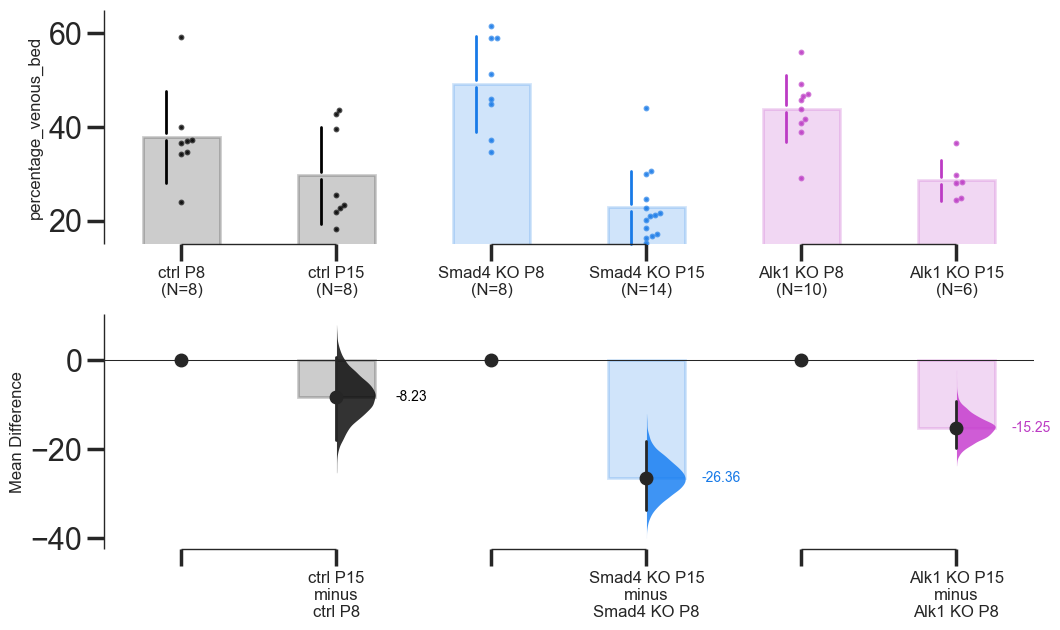

In [36]:
# ---------- Build the long DF for venous bed ----------
ctrl_p8   = summary_data.loc[(summary_data["condition"]=="control")  & (summary_data["collection_time"]==8),
                             "percentage_venous_bed"].to_numpy()
ctrl_p15  = summary_data.loc[(summary_data["condition"]=="control")  & (summary_data["collection_time"]==15),
                             "percentage_venous_bed"].to_numpy()
smad4_p8  = summary_data.loc[(summary_data["condition"]=="SMAD4-KO") & (summary_data["collection_time"]==8),
                             "percentage_venous_bed"].to_numpy()
smad4_p15 = summary_data.loc[(summary_data["condition"]=="SMAD4-KO") & (summary_data["collection_time"]==15),
                             "percentage_venous_bed"].to_numpy()
alk1_p8   = summary_data.loc[(summary_data["condition"]=="ALK1-KO")  & (summary_data["collection_time"]==8),
                             "percentage_venous_bed"].to_numpy()
alk1_p15  = summary_data.loc[(summary_data["condition"]=="ALK1-KO")  & (summary_data["collection_time"]==15),
                             "percentage_venous_bed"].to_numpy()

frames = [
    pd.DataFrame({"percentage_venous_bed": ctrl_p8,   "condition": "ctrl P8"}),
    pd.DataFrame({"percentage_venous_bed": ctrl_p15,  "condition": "ctrl P15"}),
    pd.DataFrame({"percentage_venous_bed": smad4_p8,  "condition": "Smad4 KO P8"}),
    pd.DataFrame({"percentage_venous_bed": smad4_p15, "condition": "Smad4 KO P15"}),
    pd.DataFrame({"percentage_venous_bed": alk1_p8,   "condition": "Alk1 KO P8"}),
    pd.DataFrame({"percentage_venous_bed": alk1_p15,  "condition": "Alk1 KO P15"}),
]
plot_df = pd.concat(frames, ignore_index=True)

# Keep a consistent plotting order
order = ["ctrl P8","ctrl P15","Smad4 KO P8","Smad4 KO P15","Alk1 KO P8","Alk1 KO P15"]
plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=order, ordered=True)

# Ensure your palette has the correct hex strings (note the leading '#')
time_condition_palette = {
    "ctrl P8": "#000000",  "ctrl P15": "#000000",
    "Smad4 KO P8": "#0D79F2", "Smad4 KO P15": "#0D79F2",
    "Alk1 KO P8": "#C333CC",  "Alk1 KO P15": "#C333CC",
}

# ---------- DABEST: pair P8 vs P15 within each condition ----------
properties_dabest = dabest.load(
    data=plot_df, x="condition", y="percentage_venous_bed",
    idx=(("ctrl P8","ctrl P15"),
         ("Smad4 KO P8","Smad4 KO P15"),
         ("Alk1 KO P8","Alk1 KO P15"))
)

print(properties_dabest.mean_diff)
display(properties_dabest.mean_diff.results)

# Nice y-limits based on data
y_lo = max(0, np.floor(plot_df["percentage_venous_bed"].min()/5)*5)
y_hi = np.ceil(plot_df["percentage_venous_bed"].max()/5)*5

fig = properties_dabest.mean_diff.plot(
    custom_palette=time_condition_palette,
    raw_marker_size=1.2,
    raw_alpha=0.7,
    raw_desat=0.9,
    raw_ylim=(y_lo, y_hi)
)
fig.set_size_inches(12, 7)

fig.savefig(os.path.join(out_folder, "percentage_venous_bed_P8_P15.pdf"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_folder, "percentage_venous_bed_P8_P15.png"), dpi=300, bbox_inches="tight")


C:\Users\ooppenh\AppData\Local\Temp\ipykernel_1664\3123347492.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(plot_df_p15["condition"]):


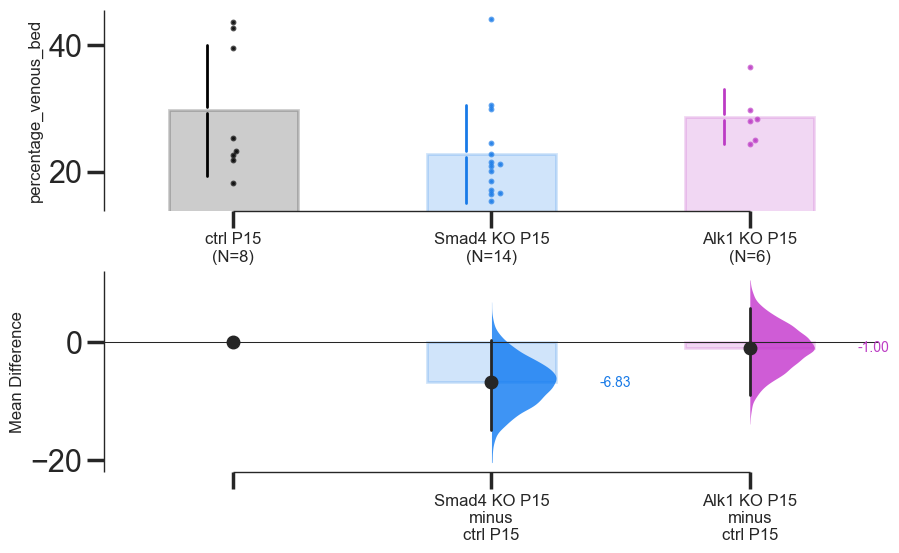

In [38]:
plot_df_p15 = plot_df.loc[plot_df["condition"].isin(["ctrl P15","Smad4 KO P15","Alk1 KO P15"])].copy()
if pd.api.types.is_categorical_dtype(plot_df_p15["condition"]):
    plot_df_p15["condition"] = plot_df_p15["condition"].cat.remove_unused_categories()

p15 = dabest.load(
    data=plot_df_p15, x="condition", y="percentage_venous_bed",
    idx=("ctrl P15","Smad4 KO P15","Alk1 KO P15")
)
fig2 = p15.mean_diff.plot(
    custom_palette={"ctrl P15":"#000000","Smad4 KO P15":"#0D79F2","Alk1 KO P15":"#C333CC"},
    raw_marker_size=1.2, raw_alpha=0.7, raw_desat=0.9
)
fig2.set_size_inches(10,6)
fig2.savefig(os.path.join(out_folder, "percentage_venous_bed_P15_shared_ctrl.pdf"), dpi=300, bbox_inches="tight")


C:\Users\ooppenh\AppData\Local\Temp\ipykernel_1664\1355969125.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(plot_df_p8["condition"]):


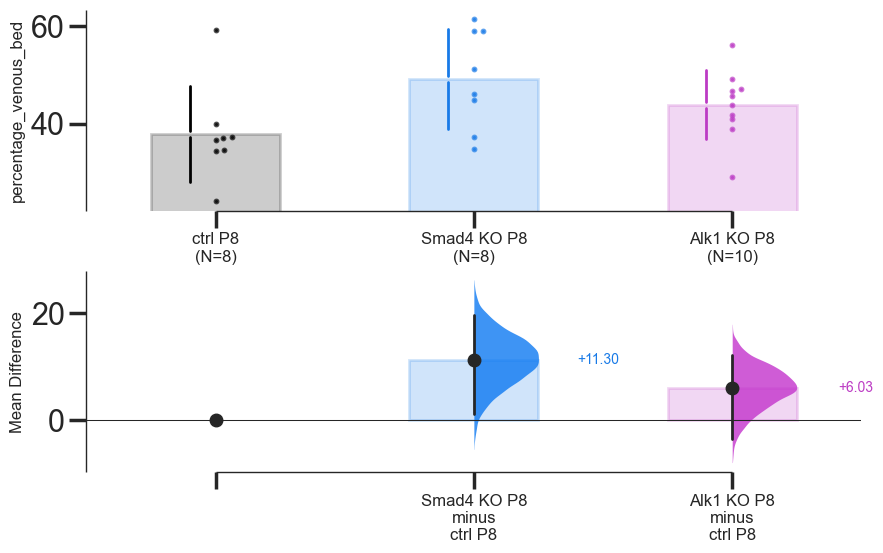

In [37]:
plot_df_p8 = plot_df.loc[plot_df["condition"].isin(["ctrl P8","Smad4 KO P8","Alk1 KO P8"])].copy()
if pd.api.types.is_categorical_dtype(plot_df_p8["condition"]):
    plot_df_p8["condition"] = plot_df_p8["condition"].cat.remove_unused_categories()

p8 = dabest.load(
    data=plot_df_p8, x="condition", y="percentage_venous_bed",
    idx=("ctrl P8","Smad4 KO P8","Alk1 KO P8")
)
fig2 = p8.mean_diff.plot(
    custom_palette={"ctrl P8":"#000000","Smad4 KO P8":"#0D79F2","Alk1 KO P8":"#C333CC"},
    raw_marker_size=1.2, raw_alpha=0.7, raw_desat=0.9
)
fig2.set_size_inches(10,6)
fig2.savefig(os.path.join(out_folder, "percentage_venous_bed_P8_shared_ctrl.pdf"), dpi=300, bbox_inches="tight")


In [71]:
def region_deltas_by_condition(summary_data, condition):
    regions = [
        "percentage_vein",
        "percentage_venous_bed",
        "percentage_arterial_bed",
        "percentage_artery"
    ]
    deltas = {}

    for region in regions:
        p8_vals = summary_data.loc[
            (summary_data["condition"] == condition) &
            (summary_data["collection_time"] == 8),
            region
        ].dropna()

        p15_vals = summary_data.loc[
            (summary_data["condition"] == condition) &
            (summary_data["collection_time"] == 15),
            region
        ].dropna()

        delta = p15_vals.mean() - p8_vals.mean()
        deltas[region] = delta

    # Sum of deltas across regions
    total = sum(deltas.values())
    return deltas, total


In [72]:
ctrl_deltas, ctrl_total = region_deltas_by_condition(summary_data, "control")
smad4_deltas, smad4_total = region_deltas_by_condition(summary_data, "SMAD4-KO")
alk1_deltas, alk1_total = region_deltas_by_condition(summary_data, "ALK1-KO")

print("Control deltas:", ctrl_deltas)
print("Control total:", ctrl_total)

print("SMAD4 deltas:", smad4_deltas)
print("SMAD4 total:", smad4_total)

print("ALK1 deltas:", alk1_deltas)
print("ALK1 total:", alk1_total)

print(f"\nΔ(Smad4 vs Ctrl): {smad4_total - ctrl_total:.2f}")
print(f"Δ(Alk1 vs Ctrl): {alk1_total - ctrl_total:.2f}")


Control deltas: {'percentage_vein': np.float64(-0.8417211555425013), 'percentage_venous_bed': np.float64(-8.229519725772022), 'percentage_arterial_bed': np.float64(6.079782239138204), 'percentage_artery': np.float64(2.708451900499216)}
Control total: -0.28300674167710316
SMAD4 deltas: {'percentage_vein': np.float64(-0.767348863750434), 'percentage_venous_bed': np.float64(-26.357496296474253), 'percentage_arterial_bed': np.float64(19.976158375527064), 'percentage_artery': np.float64(7.254532651701614)}
SMAD4 total: 0.1058458670039899
ALK1 deltas: {'percentage_vein': np.float64(-1.4079905107191322), 'percentage_venous_bed': np.float64(-15.251676474751324), 'percentage_arterial_bed': np.float64(10.4985573662629), 'percentage_artery': np.float64(6.233056833272769)}
ALK1 total: 0.07194721406521509

Δ(Smad4 vs Ctrl): 0.39
Δ(Alk1 vs Ctrl): 0.35


In [73]:
def bootstrap_unpaired_diff(group1, group2, n_boot=5000, seed=42):
    np.random.seed(seed)
    diffs = []
    for _ in range(n_boot):
        sample1 = np.random.choice(group1, size=len(group1), replace=True)
        sample2 = np.random.choice(group2, size=len(group2), replace=True)
        diffs.append(np.mean(sample2) - np.mean(sample1))
    ci = np.percentile(diffs, [2.5, 97.5])
    return np.mean(diffs), ci, diffs


In [74]:
# Get within-condition changes (P15 - P8)
ctrl_diff, ctrl_ci, _ = bootstrap_unpaired_diff(ctrl_p8, ctrl_p15)
smad4_diff, smad4_ci, _ = bootstrap_unpaired_diff(smad4_p8, smad4_p15)
alk1_diff, alk1_ci, _ = bootstrap_unpaired_diff(alk1_p8, alk1_p15)

print(f"Control   P15 - P8: {ctrl_diff:.2f} [95% CI: {ctrl_ci[0]:.2f}, {ctrl_ci[1]:.2f}]")
print(f"SMAD4 KO  P15 - P8: {smad4_diff:.2f} [95% CI: {smad4_ci[0]:.2f}, {smad4_ci[1]:.2f}]")
print(f"ALK1 KO   P15 - P8: {alk1_diff:.2f} [95% CI: {alk1_ci[0]:.2f}, {alk1_ci[1]:.2f}]")


Control   P15 - P8: -0.29 [95% CI: -1.03, 0.17]
SMAD4 KO  P15 - P8: 0.11 [95% CI: -0.01, 0.24]
ALK1 KO   P15 - P8: 0.07 [95% CI: 0.01, 0.14]


In [69]:
# Compare delta vs control
smad4_vs_ctrl = smad4_diff - ctrl_diff
alk1_vs_ctrl = alk1_diff - ctrl_diff

print(f"Δ(Smad4 KO vs Ctrl): {smad4_vs_ctrl:.2f}")
print(f"Δ(Alk1 KO vs Ctrl):  {alk1_vs_ctrl:.2f}")


Δ(Smad4 KO vs Ctrl): 0.40
Δ(Alk1 KO vs Ctrl):  0.36


In [75]:
# Bootstrap difference of differences
_, _, ctrl_samples = bootstrap_unpaired_diff(ctrl_p8, ctrl_p15)
_, _, smad4_samples = bootstrap_unpaired_diff(smad4_p8, smad4_p15)
_, _, alk1_samples = bootstrap_unpaired_diff(alk1_p8, alk1_p15)

smad4_vs_ctrl_dist = np.array(smad4_samples) - np.array(ctrl_samples)
alk1_vs_ctrl_dist = np.array(alk1_samples) - np.array(ctrl_samples)

ci_smad4_vs_ctrl = np.percentile(smad4_vs_ctrl_dist, [2.5, 97.5])
ci_alk1_vs_ctrl = np.percentile(alk1_vs_ctrl_dist, [2.5, 97.5])

print(f"Δ(Smad4 KO vs Ctrl): {smad4_vs_ctrl:.2f} [95% CI: {ci_smad4_vs_ctrl[0]:.2f}, {ci_smad4_vs_ctrl[1]:.2f}]")
print(f"Δ(Alk1 KO vs Ctrl):  {alk1_vs_ctrl:.2f} [95% CI: {ci_alk1_vs_ctrl[0]:.2f}, {ci_alk1_vs_ctrl[1]:.2f}]")


Δ(Smad4 KO vs Ctrl): 0.40 [95% CI: -0.10, 1.16]
Δ(Alk1 KO vs Ctrl):  0.36 [95% CI: -0.11, 1.10]
